In [2]:
from IPython.display import Image

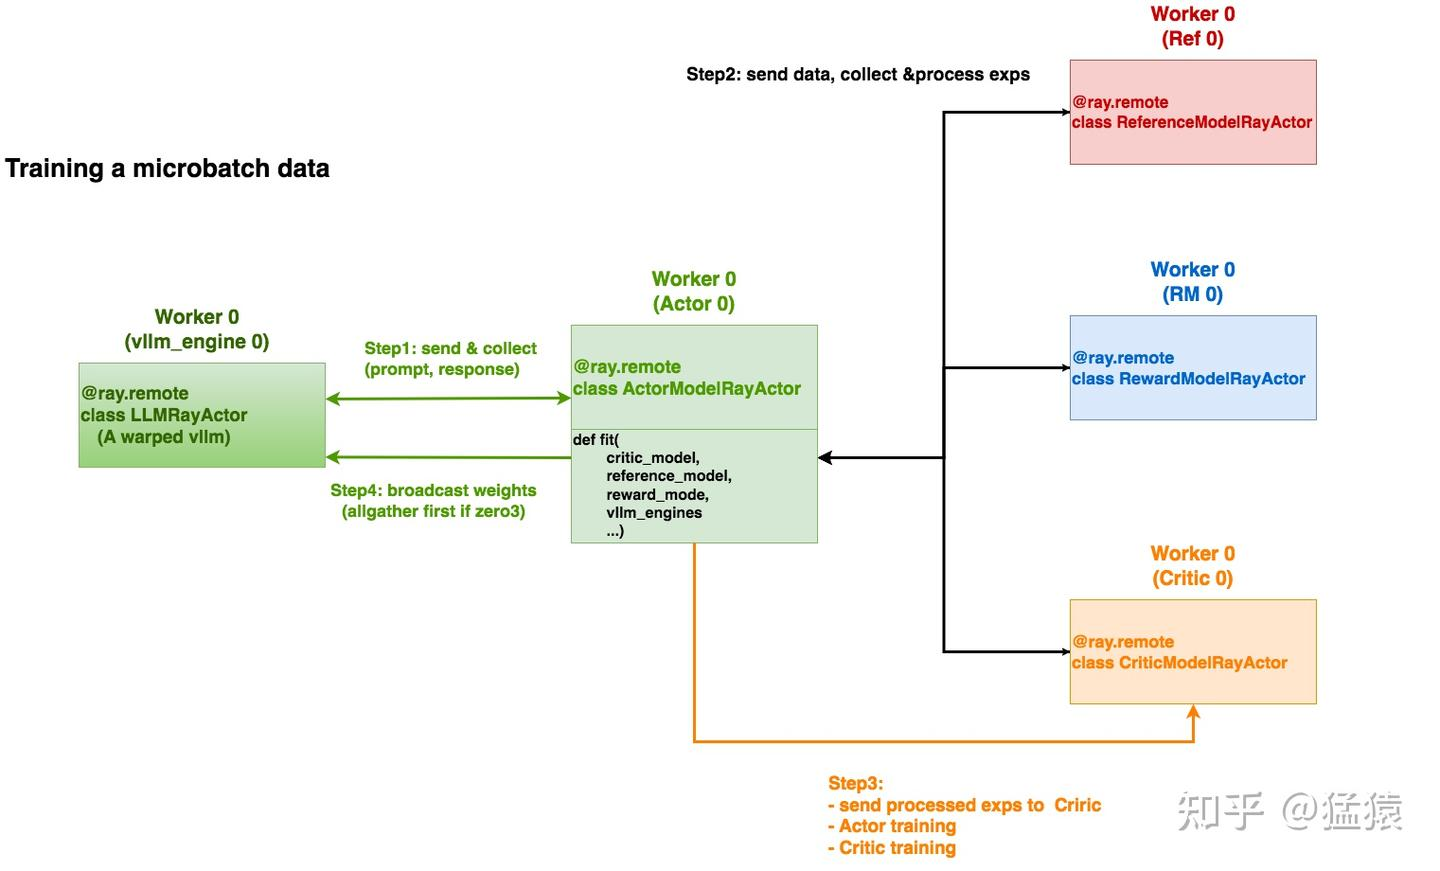

In [5]:
Image(filename='./image/train-vllm.jpg')

# PPO-Actor/Critic Training

- 正如2.1（4）中所说，我们将部署在ray集群上的PPO-Actor/Ref/Critic/RM实例们进行分组，每组分别负责一份micro-batch的训练，上图刻画了某个组内的训练流程。一组内的训练流程发起自PPO-Actor实例（fit方法），注意不同颜色的worker0表示的是不同工作进程。共分成如下步骤执行。
    - Step1：<font color='red'>发送prompts，并从vllm_engine上收集(prompt, response)</font>
    - Step2：<font color='red'>从Ref/Reward/Critic上收集并处理exps</font>
    - Step3：<font color='red'>确保将处理后的exps传送给Critic，并行执行Actor和Critic的训练</font>
    - Step4：<font color='red'>vllm_engine权重更新</font>

## Step1：发送prompts，并从vllm_engine上收集(prompt, response)。

- 代码参见：https://github.com/OpenRLHF/OpenRLHF/blob/bb46342711a203c457df2fbca5967fd0549557e0/openrlhf/trainer/ppo_utils/experience_maker.py#L627




In [ ]:
    def _generate_vllm(self, all_prompts: List[str], **kwargs) -> List[Samples]:
        from vllm import SamplingParams

        # round-robin load balance
        rank = torch.distributed.get_rank()
        world_size = torch.distributed.get_world_size()

        # Select LLM engines: assign each rank an engine, or cycle through engines if world_size < engine_count
        if len(self.vllm_engines) <= world_size:
            llms = [self.vllm_engines[rank % len(self.vllm_engines)]]
        else:
            llms = self.vllm_engines[rank::world_size]

        args = self.strategy.args

        sampling_params = SamplingParams(
            temperature=kwargs.get("temperature", 1.0),
            top_p=kwargs.get("top_p", 1.0),
            top_k=kwargs.get("top_k", -1),
            max_tokens=kwargs.get("max_new_tokens", 1024),
            min_tokens=kwargs.get("min_new_tokens", 1),
            skip_special_tokens=kwargs.get("skip_special_tokens", False),
        )

        # Expand prompt list based on the number of samples per prompt
        all_prompts = sum([[prompt] * args.n_samples_per_prompt for prompt in all_prompts], [])
        all_prompt_token_ids = self.tokenize_fn(all_prompts, self.prompt_max_len, padding=False)["input_ids"]

        # Distribute requests to engines and collect responses to outputs
        all_output_refs = []
        batch_size = (len(all_prompt_token_ids) + len(llms) - 1) // len(llms)
        for i, llm in enumerate(llms):
            prompt_token_ids = all_prompt_token_ids[i * batch_size : (i + 1) * batch_size]
            if prompt_token_ids:
                all_output_refs.append(
                    llm.generate.remote(sampling_params=sampling_params, prompt_token_ids=prompt_token_ids)
                )

        # Retrieve and combine results from all outputs
        all_outputs = sum(ray.get(all_output_refs), [])

        samples_list = []
        for i in range(0, len(all_outputs), args.micro_rollout_batch_size):
            outputs = all_outputs[i : i + self.strategy.args.micro_rollout_batch_size]
            if not self.packing_samples:
                # NOTE: concat all outputs to following format:
                #
                # | [PAD] [PAD] token token token | token token [EOS] [PAD] |
                # | token token token token token | token token [EOS] [PAD] |
                # | [PAD] [PAD] [PAD] token token | token token token [EOS] |
                # |<---------- prompt ----------->|<-------- answer ------->|
                max_input_len, max_output_len = 0, 0
                for output in outputs:
                    max_input_len = max(max_input_len, len(output.prompt_token_ids))
                    max_output_len = max(max_output_len, len(output.outputs[0].token_ids))

                pad_token_id, eos_token_id = self.tokenizer.pad_token_id, self.tokenizer.eos_token_id
                sequences = []
                for output in outputs:
                    # left padding input
                    input_len = len(output.prompt_token_ids)
                    input_ids = [pad_token_id] * (max_input_len - input_len) + list(output.prompt_token_ids)

                    # right padding output
                    output_len = len(output.outputs[0].token_ids)
                    output_ids = list(output.outputs[0].token_ids) + [pad_token_id] * (max_output_len - output_len)

                    if output_ids[output_len - 1] != eos_token_id:
                        output_ids[min(output_len, len(output_ids) - 1)] = eos_token_id

                    # concat input and output
                    sequences.append(input_ids + output_ids)

                sequences = torch.tensor(sequences)
                sequences, attention_mask, action_mask = self.actor.process_sequences(
                    sequences, max_input_len, eos_token_id, pad_token_id
                )
                sequences = sequences.to("cuda")
                attention_mask = attention_mask.to("cuda")
                action_mask = action_mask.to("cuda")
                samples_list.append(
                    Samples(
                        sequences=sequences,
                        attention_mask=attention_mask,
                        action_mask=action_mask,
                        num_actions=action_mask.size(1),
                        packed_seq_lens=None,
                        response_length=action_mask.float().sum(dim=-1),
                        total_length=attention_mask.float().sum(dim=-1),
                    )
                )
            else:
                # NOTE: concat all outputs to following format:
                #
                # | token token token | token token [EOS] | token token token token token | token token [EOS] | token token | token token token [EOS] |
                # |<---  prompt ----->|<---- answer ----->|<---------- prompt ----------->|<----- answer ---->|<- prompt -->|<-------- answer ------->|
                pad_token_id, eos_token_id = self.tokenizer.pad_token_id, self.tokenizer.eos_token_id
                sequences = []
                packed_seq_lens = []
                attention_mask = []
                num_actions = []
                for i, output in enumerate(outputs):
                    input_len = len(output.prompt_token_ids)
                    output_len = len(output.outputs[0].token_ids)
                    packed_seq_lens.append(input_len + output_len)
                    sequences.extend(output.prompt_token_ids + list(output.outputs[0].token_ids))
                    attention_mask.extend([i + 1] * (input_len + output_len))

                    # current_action_mask = [0] * (input_len - 1) + [1] * output_len + [0]
                    # num_actions.append(max(1, sum(current_action_mask)))
                    num_actions.append(max(1, output_len))

                sequences = torch.tensor(sequences, device="cuda").unsqueeze(0)
                attention_mask = torch.tensor(attention_mask, device="cuda").unsqueeze(0)
                action_mask = None
                response_length = torch.tensor(num_actions, device="cuda", dtype=torch.float)
                total_length = torch.tensor(packed_seq_lens, device="cuda", dtype=torch.float)
                samples_list.append(
                    Samples(
                        sequences=sequences,
                        attention_mask=attention_mask,
                        action_mask=None,
                        num_actions=num_actions,
                        packed_seq_lens=packed_seq_lens,
                        response_length=response_length,
                        total_length=total_length,
                    )
                )
        return samples_listm

这段代码定义了一个名为 _generate_vllm 的核心方法，
- <font color='red'>它的主要职责是利用 vLLM 引擎高效地生成文本数据（Samples），通常用于强化学习（如 PPO）的训练循环中。</font>

简单来说，它的工作流程是：
- <font color='red'>接收一批提示词（prompts），通过分布式和并行的方式调用 vLLM 进行文本生成，然后将生成的原始文本结果处理成模型训练所需的张量格式（如 Tensor）。</font>

下面我将分步详细解释这段代码的逻辑。

### 🎯 代码目的与背景
- 在结合了 DeepSpeed（训练）和 vLLM（推理）的架构中，训练器（Trainer）需要不断地让策略模型（Actor）根据当前的提示词生成新的回答，这些“提示词-回答”对 ,就是训练数据。
- <font color='red'>_generate_vllm 方法就是这个数据生成环节的“指挥官”，它负责协调多个 vLLM 引擎，高效地完成大批量数据的生成任务。</font>
### ⚙️ 逻辑分步解析
#### 1. 负载均衡与引擎选择

In [ ]:
# round-robin load balance
rank = torch.distributed.get_rank()
world_size = torch.distributed.get_world_size()

# Select LLM engines...

# 场景一：vLLM 引擎数量 <= 训练进程数量
# 例如：2个引擎，8个进程。采用轮询方式，避免多个进程争抢同一个引擎。
if len(self.vllm_engines) <= world_size:
    llms = [self.vllm_engines[rank % len(self.vllm_engines)]]
else:
# 场景二：vLLM 引擎数量 > 训练进程数量 (即我们讨论的代码)
# 例如：8个引擎，4个进程。采用跨步切片方式，让每个进程负责一部分引擎。
    llms = self.vllm_engines[rank::world_size]

这段代码实现了分布式环境下的负载均衡。
- 目标：确保每个 DeepSpeed 进程（rank）都能公平地使用 vLLM 引擎资源，避免所有进程都去请求同一个 vLLM 引擎造成瓶颈。
- 逻辑：
    - 如果 vLLM 引擎数量少于或等于 DeepSpeed 进程数，则采用轮询方式，每个 rank 分配一个引擎。
    - 如果 vLLM 引擎数量更多，则采用跨步切片（rank::world_size），让每个 rank 负责一部分引擎。
#### 2. 配置采样参数与数据预处理

In [ ]:
args = self.strategy.args
sampling_params = SamplingParams(...)

# Expand prompt list based on the number of samples per prompt
all_prompts = sum([[prompt] * args.n_samples_per_prompt for prompt in all_prompts], [])
all_prompt_token_ids = self.tokenize_fn(all_prompts, self.prompt_max_len, padding=False)["input_ids"]

- <font color='red'>SamplingParams</font>: 
    - 这是 vLLM 的核心配置对象，定义了生成时的超参数，
    - 如 temperature（温度）、top_p、max_tokens（最大生成长度）等。
    
- 数据扩充: 为了增加数据的多样性，代码会将每个 prompt 复制 n_samples_per_prompt 份。例如，一个 prompt 要求生成 4 个样本，这里就会变成 4 个相同的 prompt 发送给 vLLM。
- 分词: 将扩充后的 prompt 列表转换为 token IDs，这是 vLLM 能够处理的格式。

##### sum() 函数：压平列表

In [ ]:
sum(..., [])

这是 Python 中一个非常巧妙但不太常见的用法。通常 sum() 用于数字求和，但它也可以用于合并序列。
- sum(iterable, start) 的工作原理是：start + iterable[0] + iterable[1] + ...。
- 在这里，start 参数被设置为一个空列表 []。
- 因此，sum() 会执行列表的加法操作：[] + ["问题A", "问题A"] + ["问题B", "问题B"]。

在 Python 中，列表相加意味着拼接（concatenation）。所以这个操作会将二维列表中的所有子列表连接起来，形成一个新的一维列表。

📌 完整流程示例
让我们把两部分结合起来看：

In [ ]:
# 假设输入
all_prompts = ["问题A", "问题B", "问题C"]
args.n_samples_per_prompt = 2

# 1. 列表推导式生成嵌套列表
nested_list = [["问题A", "问题A"], ["问题B", "问题B"], ["问题C", "问题C"]]

# 2. sum函数将嵌套列表压平
# 相当于执行: [] + ["问题A", "问题A"] + ["问题B", "问题B"] + ["问题C", "问题C"]
flattened_list = sum(nested_list, [])

# 最终结果
# flattened_list = ["问题A", "问题A", "问题B", "问题B", "问题C", "问题C"]

###### 💡 替代方案与性能说明

虽然这种 sum 用法非常简洁，但值得注意的是，对于非常大的列表，它的性能并不是最优的，因为它会创建许多中间列表对象。

在其他场景下，你可能会看到以下替代方案，它们的功能完全相同：
- 列表推导式（<font color='red'>更推荐，性能更好</font>）

In [ ]:
[prompt for prompt in all_prompts for _ in range(args.n_samples_per_prompt)]

- itertools.chain.from_iterable

In [ ]:
import itertools
list(itertools.chain.from_iterable([prompt] * args.n_samples_per_prompt for prompt in all_prompts))

#### 3. 分布式并行生成

In [ ]:
# Distribute requests to engines and collect responses to outputs
all_output_refs = []

batch_size = (len(all_prompt_token_ids) + len(llms) - 1) // len(llms)

for i, llm in enumerate(llms):
    
    prompt_token_ids = all_prompt_token_ids[i * batch_size : (i + 1) * batch_size]
    if prompt_token_ids:
        
        all_output_refs.append(
            llm.generate.remote(sampling_params=sampling_params, prompt_token_ids=prompt_token_ids)
        )

这是整个方法性能优化的关键。
- 分片: 将待处理的 prompt_token_ids 均匀地切分成多个批次（batches）。
- 异步远程调用: <font color='red'>使用 Ray 的 llm.generate.remote() 异步地向每个 vLLM 引擎发送生成请求。</font>
    - <font color='green'>这不会阻塞当前进程，所有请求会几乎同时发出。</font>
    - <font color='red'>all_output_refs 是一个 ObjectRef 列表，代表未来会返回的结果。</font>
    
#### 4. 结果收集

In [ ]:
# Retrieve and combine results from all outputs
all_outputs = sum(ray.get(all_output_refs), [])

- ray.get(...): 这是一个阻塞调用。它会等待所有异步的生成任务完成，并获取所有 vLLM 引擎返回的原始结果。
- 合并:<font color='red'> 将所有引擎返回的结果列表合并成一个大的列表 all_outputs。</font>

#### 5. 后处理：构建训练样本 (Samples)
这是代码最复杂的部分，<font color='red'>它将 vLLM 的原始输出转换成训练模型可以直接使用的 Samples 对象</font>。
- 这里分为两种模式：packing_samples=False 和 packing_samples=True。

##### 模式一：packing_samples=False (<font color='red'>非打包模式</font>)

In [ ]:
# ... (省略部分代码)
# 目标格式:
# | [PAD] [PAD] token token token | token token [EOS] [PAD] |
# | token token token token token | token token [EOS] [PAD] |
# |<---------- prompt ----------->|<-------- answer ------->|

<font color='red'>这种模式采用传统的批处理方式，将所有样本填充到相同的长度。</font>

1. 计算最大长度: 遍历当前批次的所有输出，找到最长的 prompt 长度 (max_input_len) 和最长的 answer 长度 (max_output_len)。
2. 填充 (Padding):
    - 输入 (Prompt): <font color='green'>采用左填充</font>，即在 prompt 前面补 PAD token。
    - 输出 (Answer): <font color='red'>采用右填充</font>，即在 answer 后面补 PAD token。
3. 拼接与掩码: 将填充后的 input 和 output 拼接成一个完整的序列。然后调用 self.actor.process_sequences 生成 attention_mask（<font color='red'>注意力掩码，告诉模型哪些是真实数据</font>）和 action_mask（<font color='red'>动作掩码，告诉模型哪些 token 是由当前策略生成的，需要计算损失</font>）。
4. 构建 Samples: 将处理好的张量封装到 Samples 对象中。

##### 模式二：packing_samples=True (打包模式)

In [ ]:
# ... (省略部分代码)
# 目标格式:
# | token token token | token token [EOS] | token token token token token | token token [EOS] | ...
# |<---  prompt ----->|<---- answer ----->|<---------- prompt ----------->|<----- answer ---->|

<font color='red'>这种模式采用序列打包技术，将多个“prompt-answer”对首尾相连，塞进一个超长的序列中，以最大化 GPU 利用率，减少计算浪费。</font>

1. 扁平化拼接: 不再进行填充，而是直接将所有“prompt + answer”的 token IDs 首尾相连，形成一个超长的 1D 序列。
2. 位置编码: attention_mask 在这里不再只是 0/1，而是存储了每个 token 在原始序列中的位置信息（或序列索引），以便模型能区分不同的样本。
3. 长度记录:
    - packed_seq_lens <font color='green'>记录了每个“prompt-answer”对的长度，</font>
    - response_length <font color='green'>记录了每个 answer 的长度。这些信息对于后续计算损失至关重要。</font>

### 📌 总结

_generate_vllm 是一个高度优化的数据生成管道，它巧妙地结合了以下技术：
- 分布式负载均衡: 充分利用多 GPU 和多 vLLM 引擎的资源。
- 异步并行 I/O: 通过 Ray 实现非阻塞的远程调用，极大提升了吞吐量。
- 灵活的数据后处理: <font color='green'>支持传统的批处理和高效的序列打包两种模式，以适应不同的训练需求。</font>

<font color='red'>最终，它将原始的文本提示词转换成了结构化的、可用于梯度计算的 Samples 对象，是连接推理（vLLM）和训练（DeepSpeed）的关键桥梁。</font>

## Step2：从Ref/Reward/Critic上收集并处理exps。

- 代码参见：https://github.com/OpenRLHF/OpenRLHF/blob/bb46342711a203c457df2fbca5967fd0549557e0/openrlhf/trainer/ppo_utils/experience_maker.py#L492


In [ ]:
    @torch.no_grad()
    def make_experience(self, samples: Samples) -> Experience:
        """
        Turn samples into experience by calculating logprobs, values, rewards, and kl divergence.
        """
        self.actor.eval()
        device = torch.cuda.current_device()

        # extract values from samples
        sequences = samples.sequences
        attention_mask = samples.attention_mask
        action_mask = samples.action_mask
        num_actions = samples.num_actions
        packed_seq_lens = samples.packed_seq_lens

        start = time.time()
        sequences_cpu, attention_mask_cpu = (
            sequences.to("cpu"),
            attention_mask.to("cpu"),
        )

        # init log probs
        base_action_log_probs_ref = self.initial_model.forward.remote(
            sequences_cpu, num_actions, attention_mask_cpu, packed_seq_lens=packed_seq_lens
        )

        # values
        if self.critic is not None:
            value_ref = self.critic.forward.remote(
                sequences_cpu, num_actions, attention_mask_cpu, packed_seq_lens=packed_seq_lens
            )
            # avoid CUDA OOM when colocate models
            if self.strategy.args.colocate_critic_reward:
                ray.get([value_ref])
                ray.get([self.critic.empty_cache.remote()])
        else:
            value_ref = ray.put(None)

        if self.strategy.args.colocate_actor_ref:
            ray.get([base_action_log_probs_ref])
            ray.get([self.initial_model.empty_cache.remote()])

        # rewards
        r_refs = []
        # support remote RM API with ray
        if not self.remote_rm_url:
            for rm in self.reward_model:
                r_refs.append(rm.forward.remote(sequences_cpu, attention_mask_cpu, packed_seq_lens=packed_seq_lens))
        else:
            # remote RM
            if not self.packing_samples:
                queries = self.tokenizer.batch_decode(sequences_cpu, skip_special_tokens=False)
            else:
                sequences_list = []
                offset = 0
                tokens_list = sequences_cpu.tolist()[0]
                for length in packed_seq_lens:
                    sequences_list.append(tokens_list[offset : offset + length])
                    offset += length
                queries = self.tokenizer.batch_decode(sequences_list, skip_special_tokens=False)

            for rm in self.remote_rm_url:
                r = remote_rm_fn_ray.remote(rm, queries=queries)
                r_refs.append(r)

        # log probs
        action_log_probs = self.actor(sequences, num_actions, attention_mask, packed_seq_lens=packed_seq_lens)
        actor_value_rm_time = time.time() - start

        # wait initial/critic/reward model done
        start = time.time()
        ref_values = ray.get([base_action_log_probs_ref, value_ref] + r_refs)
        wait_time = time.time() - start

        base_action_log_probs, value, rewards = ref_values[0], ref_values[1], ref_values[2:]
        base_action_log_probs = base_action_log_probs.to(device)
        if value is not None:
            value = value.to(device)
        rewards = [r.to(device) for r in rewards]
        r = self.reward_fn(rewards) if len(rewards) > 0 else rewards[0]

        # avoid CUDA OOM when colocate models
        if self.strategy.args.colocate_critic_reward and not self.remote_rm_url:
            ray.get([self.reward_model[0].empty_cache.remote()])

        if self.strategy.args.colocate_actor_ref:
            torch.cuda.empty_cache()

        kl = compute_approx_kl(
            action_log_probs,
            base_action_log_probs,
            action_mask=action_mask,
            use_kl_estimator_k3=self.strategy.args.use_kl_estimator_k3,
        )

        if not self.packing_samples:
            kl_mean = masked_mean(kl, action_mask, dim=-1)
        else:
            # convert tensor into list of tensors so that it's easier to manipulate
            # within dataset.
            sequences = unpacking_samples(sequences, packed_seq_lens)
            attention_mask = None
            action_log_probs = unpacking_samples(action_log_probs, num_actions)
            if value is not None:
                value = unpacking_samples(value, num_actions)

            kl = unpacking_samples(kl, num_actions)
            kl_mean = torch.tensor([each_kl.mean() for each_kl in kl], device=device)

        info = {
            "kl": kl_mean,
            "reward": r,
            "response_length": samples.response_length,
            "total_length": samples.total_length,
            "num_actions": num_actions,
        }

        if self.strategy.args.perf:
            self.perf_stats["actor_value_rm_time"] += actor_value_rm_time
            self.perf_stats["wait_time"] += wait_time

        experience = Experience(
            sequences,
            action_log_probs,
            value,
            None,
            None,
            attention_mask,
            action_mask,
            info,
            kl,
        )

        self.actor.train()  # reset model state
        return experience

这段代码定义了 make_experience 方法，它是强化学习（特别是 PPO）训练循环中的核心环节。
- <font color='red'>它的主要职责是将模型生成的原始样本（Samples）转化为包含丰富反馈信息的“经验”（Experience）。这个“经验”是后续更新模型策略的直接依据。</font>

简单来说， <font color='green'>make_experience 会计算生成每个动作（token）的对数概率（logprobs）、价值（values）和奖励（rewards），并评估新旧策略之间的KL散度（KL divergence）。</font>

下面我将分步详细解释这段代码的逻辑。

### 🎯 代码目的与背景

在 PPO 算法中，训练过程分为两步：
1. 生成经验 (Make Experience): 让当前的策略模型（Actor）根据提示词生成回答。
2. 学习经验 (Learn from Experience): 根据这些回答的“好坏”（奖励）来更新模型。

make_experience 就是第一步的后半部分。
- 它接收上一步生成的 Samples，
- 然后通过调用多个模型（Actor, Critic, Reward Model, Reference Model）来计算一系列指标，
- 最终打包成一个 Experience 对象，供训练器使用。

### ⚙️ 逻辑分步解析
#### 1. 准备阶段与异步计算启动

In [ ]:
self.actor.eval() # 将Actor模型设为评估模式，禁用Dropout等
device = torch.cuda.current_device()

# 将数据移至CPU，为后续异步操作做准备
sequences_cpu, attention_mask_cpu = sequences.to("cpu"), attention_mask.to("cpu")

start = time.time()
# 1. 异步调用参考模型 (Initial Model) 计算旧策略的 logprobs
base_action_log_probs_ref = self.initial_model.forward.remote(sequences_cpu, ...)

# 2. 异步调用价值模型 (Critic) 计算状态价值
if self.critic is not None:
    value_ref = self.critic.forward.remote(sequences_cpu, ...)
    # 如果Critic和Reward Model共用显存，先执行完Critic计算并清空缓存
    if self.strategy.args.colocate_critic_reward:
        ray.get([value_ref])
        ray.get([self.critic.empty_cache.remote()])
else:
    value_ref = ray.put(None)

- @torch.no_grad(): 这是一个装饰器，确保此函数内的所有 PyTorch 操作都不计算梯度，节省显存和计算资源。
- 异步计算: 代码的核心优化思想。它将耗时的模型前向推理（Forward Pass）通过 Ray 的 .remote() 异步发出。
    - <b>initial_model (参考模型)</b>：<font color='red'>通常是训练开始时的模型副本，用于计算 KL 散度，防止策略更新幅度过大。</font>
    - critic (价值模型)：用于评估当前状态的好坏。
- <font color='red'>显存管理: colocate_critic_reward 等标志位表明这是一个为节省显存而高度优化的系统。它允许不同的模型轮流使用同一块显存，因此需要精确地控制计算顺序和缓存清理（empty_cache）。</font>

#### 2. 异步计算奖励 (Rewards)

In [ ]:
r_refs = []
if not self.remote_rm_url:
    # 本地 Reward Model
    for rm in self.reward_model:
        r_refs.append(rm.forward.remote(sequences_cpu, ...))
else:
    # 远程 Reward Model (API)
    # 1. 将 token IDs 解码回文本
    if not self.packing_samples:
        queries = self.tokenizer.batch_decode(sequences_cpu, ...)
    else:
        # 处理打包的序列，解包后解码
        # ...
        queries = self.tokenizer.batch_decode(sequences_list, ...)
        
    # 2. 异步调用远程API
    for rm in self.remote_rm_url:
        r = remote_rm_fn_ray.remote(rm, queries=queries)
        r_refs.append(r)

- 灵活的奖励计算: 代码支持两种奖励模型（RM）模式：
    - 本地 RM: 一个在本地运行的 PyTorch 模型，通过 Ray 异步调用。
    - 远程 RM: 一个外部的 API 服务（例如，一个用于评估代码质量的 LLM API）。代码会先将序列解码成文本，再通过网络请求发送给 API。
    
#### 3. 同步计算与结果收集

In [ ]:
# 3. 同步计算当前Actor的 logprobs (必须在GPU上)
action_log_probs = self.actor(sequences, num_actions, attention_mask, ...)

# 4. 等待所有异步任务完成
start = time.time()
ref_values = ray.get([base_action_log_probs_ref, value_ref] + r_refs)
wait_time = time.time() - start

base_action_log_probs, value, rewards = ref_values[0], ref_values[1], ref_values[2:]
# 将所有结果移回GPU
# ...

- 关键路径: <font color='green'>当前 actor 的 action_log_probs 计算是同步的，因为它需要立即使用 GPU 上的 sequences 数据。</font>
- ray.get(...): 这是一个阻塞点。<font color='green'>主进程在这里等待所有之前异步发出的任务（参考模型、价值模型、奖励模型的计算）全部完成。</font>
- 性能分析: 代码通过 start 和 time.time() 精确记录了计算时间 (actor_value_rm_time) 和等待时间 (wait_time)，这对于性能调优至关重要。

#### 4. 计算 KL 散度与处理打包数据

In [ ]:
# 计算新旧策略的 KL 散度
kl = compute_approx_kl(action_log_probs, base_action_log_probs, ...)

# 处理打包和非打包两种数据格式
if not self.packing_samples:
    # 非打包模式：直接计算平均KL
    kl_mean = masked_mean(kl, action_mask, dim=-1)
else:
    # 打包模式：需要先解包，再对每个样本分别计算平均KL
    sequences = unpacking_samples(sequences, packed_seq_lens)
    # ...
    kl = unpacking_samples(kl, num_actions)
    kl_mean = torch.tensor([each_kl.mean() for each_kl in kl], device=device)

- KL 散度: 这是 PPO 算法的核心，用于衡量新旧策略的差异。compute_approx_kl 函数计算每个 token 的 KL 散度。
- 数据解包: 如果使用了序列打包（packing_samples=True），所有样本都挤在一个长序列里。在计算完逐 token 的指标后，需要使用 unpacking_samples 函数将它们拆分成独立的样本，以便后续处理。

#### 5. 构建并返回 Experience

In [ ]:
info = {
    "kl": kl_mean,
    "reward": r,
    "response_length": samples.response_length,
    # ... 其他统计信息
}

experience = Experience(
    sequences,
    action_log_probs,
    value,
    None, # advantages (通常在后续步骤计算)
    None, # returns (通常在后续步骤计算)
    attention_mask,
    action_mask,
    info,
    kl,
)

self.actor.train()  # 将Actor模型设回训练模式
return experience

- <font color='red'>信息汇总: 将所有计算出的指标（KL、奖励、长度等）放入 info 字典，用于日志记录和监控。</font>
- 打包: 将所有数据和信息封装到 Experience 对象中。
- 状态恢复: <font color='red'>最后，将 actor 模型从 eval() 模式设回 train() 模式，为接下来的梯度更新做准备。</font>

### 📌 总结

make_experience 是一个高度工程化的方法，它巧妙地结合了以下技术：

- 异步并行计算: 通过 Ray 将参考模型、价值模型和奖励模型的计算并行化，与当前 Actor 的计算重叠，极大提升了效率。
- <font color='red'>精细的显存管理: 通过 colocate 标志和 empty_cache 调用，在有限的显存中轮流运行多个大模型。</font>
- 灵活的数据格式支持: 同时支持传统的批处理和高效的序列打包两种模式。
- 精确的性能分析: 内置计时器，为系统优化提供了关键数据。

它是连接模型推理和策略更新的核心桥梁，负责收集训练所需的所有“经验”数据。

## Step3: 确保将处理后的exps传送给Critic，并行执行Actor和Critic的训练

- 将exps传送给Critic：https://github.com/OpenRLHF/OpenRLHF/blob/bb46342711a203c457df2fbca5967fd0549557e0/openrlhf/trainer/ppo_utils/experience_maker.py#L470



In [ ]:
    @torch.no_grad()
    def make_experience_list(self, all_prompts: Union[str, List[str]], **generate_kwargs) -> List[Experience]:
        if self.strategy.args.perf:
            self.perf_stats = {
                "generate_time": 0,
                "actor_value_rm_time": 0,
                "wait_time": 0,
            }
            
        experiences = super().make_experience_list(all_prompts, **generate_kwargs)
        if self.critic is not None:
            for experience in experiences:
                # 将exps传送给Critic send experience to critic
                experience_cpu = deepcopy(experience)
                experience_cpu.to_device("cpu")
                self._ref = self.critic.append.remote(experience_cpu)
        return experiences

这段代码定义了 make_experience_list 方法，它是强化学习训练流程中一个承上启下的关键环节。
- 它的核心职责是：<font color='red'>协调整个“经验生成”流程，并将生成的经验异步地发送给价值模型（Critic），为后续的价值学习做准备。</font>
- 这个方法巧妙地利用了异步通信，将耗时的价值模型数据接收操作从主训练流程中剥离出来，实现了计算重叠，从而提升了整体训练效率。

下面我将分步详细解释这段代码的逻辑。

### 🎯 代码目的与背景
在 PPO 等强化学习算法的训练循环中，通常遵循以下步骤：
1. 生成经验 (Make Experience): 让 Actor 模型根据提示词生成数据，并计算奖励、KL 散度等。
2. 学习经验 (Learn from Experience): 使用这些经验来更新 Actor 和 Critic 模型。

make_experience_list 方法就是第 1 步的总入口。它不仅负责触发经验生成，还负责为第 2 步中的 Critic 更新提前准备好数据。

### ⚙️ 逻辑分步解析
#### 1. 性能监控初始化

In [ ]:
if self.strategy.args.perf:
    self.perf_stats = {
        "generate_time": 0,
        "actor_value_rm_time": 0,
        "wait_time": 0,
    }

- 目的: 这是一个可选的性能分析开关。如果开启了性能监控 (self.strategy.args.perf)，它会初始化一个字典来记录各个阶段的时间消耗。
- 意义: <font color='red'>在复杂的分布式训练中，精确了解每个环节（如生成时间、模型推理时间、通信等待时间）的耗时对于定位瓶颈、优化性能至关重要。这些指标在 make_experience 方法中会被填充。</font>

#### 2. 调用父类方法生成经验

In [ ]:
experiences = super().make_experience_list(all_prompts, **generate_kwargs)

- 核心任务: 这行代码调用了父类（通常是 PPOTrainer 的基类）的 make_experience_list 方法。
- 实际工作: <font color='red'>父类的方法会执行我们之前分析过的完整流程：</font>
    - 调用 _generate_vllm 生成 Samples。
    - 调用 make_experience 将 Samples 转化为 Experience。
- <font color='red'>结果: 执行完这行后，experiences 变量就包含了所有计算好奖励、KL 散度等信息的 Experience 对象列表。此时，主训练流程已经拿到了训练 Actor 所需的所有数据。</font>

#### 3. 异步发送经验给 Critic- 

In [ ]:
if self.critic is not None:
    for experience in experiences:
        # 将exps传送给Critic send experience to critic
        experience_cpu = deepcopy(experience)
        experience_cpu.to_device("cpu")
        self._ref = self.critic.append.remote(experience_cpu)

这是整个方法最核心的优化点，它将 Critic 的数据接收操作异步化了。
- if self.critic is not None:: 检查是否存在价值模型。在某些简化场景下可能没有 Critic。
- deepcopy(experience): 创建 experience 的一个深拷贝。这是为了防止后续操作修改原始数据，保证数据的一致性。
- experience_cpu.to_device("cpu"): 将拷贝后的经验数据从 GPU 移动到 CPU 内存。
    - <font color='red'>目的: Critic 模型可能位于不同的 GPU 上，或者为了节省当前 GPU 的显存。将数据先移到 CPU，相当于放到了一个“中转站”，方便后续的远程传输。</font>
- self.critic.append.remote(experience_cpu): 关键操作！
    - 异步调用: 使用 Ray 的 .remote() 方法，异步地调用 Critic 对象的 append 方法。
    - 非阻塞: 这行代码会立即返回，不会等待 Critic 真正接收完数据。主训练流程可以立刻继续执行下一步（例如，开始用这些经验更新 Actor 模型），而 Critic 则在后台默默地从 CPU 内存中拉取数据。
    - <font color='red'>self._ref: 保存返回的 ObjectRef。虽然这里没有立即 ray.get()，但保留引用可以防止垃圾回收，并在需要时（例如在训练结束前）进行同步。</font>
    
    
### 🚀 为什么这样做？—— 计算重叠 (Overlap)

这种设计模式的精髓在于计算重叠。

#### 如果没有异步化 (串行模式):
1. 生成所有经验 (耗时 T1)。
2. 将经验数据从 GPU 复制到 Critic (耗时 T2)。
3. 开始训练 Actor (耗时 T3)。
总耗时 = T1 + T2 + T3

#### <font color='red'>使用异步化 (并行模式)</font>:
1. 生成所有经验 (耗时 T1)。
2. 同时发生:
    - <font color='red'>主流程：开始训练 Actor (耗时 T3)。</font>
    - <font color='red'>后台任务：Critic 异步接收经验数据 (耗时 T2)。</font>
总耗时 ≈ max(T1 + T3, T1 + T2)

<font color='red'>由于 T2（数据传输）通常远小于 T3（模型训练），这种并行化可以几乎完全“隐藏”掉数据传输的开销，从而显著提升训练效率。</font>

### 📌 总结

<font color='red'>make_experience_list 方法是一个高效的“调度员”。</font>

- 它负责“生产”：通过调用父类方法，完成所有经验的生成和初步计算。
- 它负责“预投递”：通过 Ray 的异步远程调用，将生成好的经验数据提前、非阻塞地发送给 Critic 模型。

<font color='red'>这种设计确保了 Critic 模型在需要开始训练时，数据已经准备就绪，避免了主训练流程的等待，是高性能分布式强化学习框架中的一个关键优化技巧。</font>

- Actor训练：https://github.com/OpenRLHF/OpenRLHF/blob/bb46342711a203c457df2fbca5967fd0549557e0/openrlhf/trainer/ray/ppo_actor.py#L125

- Critic训练：https://github.com/OpenRLHF/OpenRLHF/blob/bb46342711a203c457df2fbca5967fd0549557e0/openrlhf/trainer/ray/ppo_actor.py#L122
我们在Actor实例所在的worker进程上出发Actor和Critic的训练。以上代码只给出了训练入口，更多细节需要顺着入口去阅读。

## Step4：vllm_engine权重更新。

- 代码参见：https://github.com/OpenRLHF/OpenRLHF/blob/bb46342711a203c457df2fbca5967fd0549557e0/openrlhf/trainer/ray/ppo_actor.py#L130

In [ ]:
 def ppo_train(self, global_steps):
        # 1. ensure all experience makers done
        self.experience_maker.flush()
        torch.distributed.barrier()

        # 2. triger remote critic model training
        if self.critic_train_remote:
            critic_status_ref = self.critic.fit.remote()

        # 3. actor model training
        if global_steps > self.freezing_actor_steps:
            status = super().ppo_train(global_steps)

            # 4. vllm_engine权重更新  :broadcast weights to vllm engines  
            if self.vllm_engines is not None:
                torch.distributed.barrier()
                self._broadcast_to_vllm()
        else:
            status = {}

        # 5. wait remote critic model training done
        if self.critic_train_remote:
            status.update(ray.get(critic_status_ref))
        torch.distributed.barrier()

        return status


这段代码定义了 ppo_train 方法，它是整个 PPO 训练循环的“总指挥”。
- 它的核心职责是：<font color='red'>精确协调 Actor 模型、Critic 模型和 vLLM 引擎之间的训练与同步，通过异步化和流水线设计，最大化分布式训练的效率和稳定性。</font>
- 这个方法确保了所有组件在正确的时间点完成各自的任务，<font color='red'>并通过巧妙的调度，让耗时的操作（如 Critic 训练）与主流程并行执行。</font>

下面我将分步详细解释这段代码的逻辑。

### 🎯 代码目的与背景

在 PPO 的训练迭代中，数据流和模型更新是高度同步的。ppo_train 方法负责管理这个复杂的流程：

1. 经验生成阶段：由 experience_maker 负责。
2. 模型更新阶段：Actor 和 Critic 模型需要根据经验进行训练。
3. 推理引擎同步阶段：训练好的 Actor 权重需要同步给 vLLM 引擎，以便进行下一轮的数据生成。

这个方法就是这三个阶段的“粘合剂”和“调度器”。
### ⚙️ 逻辑分步解析

#### 1. 确保经验生成完成

In [ ]:
# 1. ensure all experience makers done
self.experience_maker.flush()
torch.distributed.barrier()

- <font color='red'>self.experience_maker.flush(): 这是一个关键的同步点。它确保所有由 experience_maker 发起的异步操作（例如，我们之前分析过的向 Critic 发送经验的 .remote() 调用）都已经完成。可以理解为“清空管道”，确保所有经验数据都已生成并就绪。</font>
- torch.distributed.barrier(): <font color='red'>这是一个分布式屏障。它会阻塞当前进程，直到所有参与训练的进程都到达这一点。</font>
    - <font color='red'>目的: 确保整个分布式系统中的所有 GPU 都完成了经验生成阶段，大家步调一致地进入模型训练阶段。</font>
    
#### 2. 异步触发 Critic 训练

In [ ]:
# 2. triger remote critic model training
if self.critic_train_remote:
    critic_status_ref = self.critic.fit.remote()

- 异步执行: <font color='red'>这是性能优化的核心。代码通过 self.critic.fit.remote() 异步地触发 Critic 模型的训练。</font>
- 非阻塞: 这行代码会立即返回一个 ObjectRef（critic_status_ref），而不会等待 Critic 训练完成。主进程可以立刻去执行下一步（训练 Actor），而 Critic 则在后台（可能在另一个 GPU 上）独立地进行训练。
- <font color='red'>目的: 实现 Actor 和 Critic 训练的并行化，从而缩短整个训练迭代的时间。</font>

#### 3. 训练 Actor 模型并同步 vLLM

In [ ]:
# 3. actor model training
if global_steps > self.freezing_actor_steps:
    status = super().ppo_train(global_steps)

    # 4. vllm_engine权重更新
    if self.vllm_engines is not None:
        torch.distributed.barrier()
        self._broadcast_to_vllm()
else:
    status = {}

这是主训练流程的核心部分。
- if global_steps > self.freezing_actor_steps:: 这是一个常见的训练技巧，称为“预热”（Warmup）。<font color='red'>在训练的初始阶段（global_steps 较小），会先冻结 Actor 模型，只训练 Critic 模型，让 Critic 先学会如何准确地评估价值。当 global_steps 超过阈值后，才开始训练 Actor。</font>
- super().ppo_train(global_steps): <font color='red'>调用父类的 ppo_train 方法。这里会执行 Actor 模型的实际梯度更新，使用之前生成的经验数据来优化策略。</font>
- self._broadcast_to_vllm(): <font color='red'>这是连接训练和推理的关键一步。</font>
    - <font color='red'>在 Actor 模型更新后，它的权重已经改变。为了让下一轮的经验生成能基于最新的策略，必须将更新后的权重广播（broadcast）给所有 vLLM 推理引擎。这个广播操作是同步的，因为它需要确保所有 vLLM 引擎都接收完毕。<font color='red'>
#### 4. 等待 Critic 训练完成

In [ ]:
# 5. wait remote critic model training done
if self.critic_train_remote:
    status.update(ray.get(critic_status_ref))
torch.distributed.barrier()

- ray.get(critic_status_ref): <font color='red'>这是一个阻塞操作。主进程在这里等待，直到之前异步启动的 Critic 训练任务（critic.fit.remote()）完全结束。</font>
- <font color='red'>status.update(...): Critic 训练完成后，会返回一些状态信息（如损失值、梯度范数等）。这里将这些信息合并到主流程的 status 字典中，用于日志记录和监控。</font>
- <font color='red'>torch.distributed.barrier(): 最后一个分布式屏障。确保所有进程都完成了本轮 PPO 训练（包括 Actor 更新、Critic 更新和 vLLM 同步），然后才能进入下一轮迭代。</font>


### 🚀 为什么这样设计？—— 流水线并行
这种设计模式的精髓在于构建了一个高效的训练流水线。

#### 串行模式 (效率低):
1. 生成经验。
2. 训练 Critic (耗时 T_critic)。
3. 训练 Actor (耗时 T_actor)。
4. 同步 vLLM。
总耗时 ≈ T_exp + T_critic + T_actor + T_sync

#### 流水线模式 (效率高):
1. 生成经验。
2. 同时发生:
    - 主流程：训练 Actor (耗时 T_actor)。
    - 后台流程：训练 Critic (耗时 T_critic)。
3. 等待 Critic 完成 (等待时间 ≈ max(0, T_critic - T_actor))。
4. 同步 vLLM。
总耗时 ≈ T_exp + max(T_actor, T_critic) + T_sync

通过让 Critic 和 Actor 的训练并行，整个迭代周期被大大缩短。

### 📌 总结
ppo_train 方法是一个精心设计的“交响乐指挥家”。
- 它负责“同步”：通过 flush() 和 barrier() 确保所有进程步调一致。
- 它负责“并行”：通过 ray.remote() 将 Critic 的训练异步化，使其与 Actor 的训练重叠执行。
- 它负责“更新”：在 Actor 训练后，立即将新权重同步给推理引擎，保证训练-推理循环的连贯性。
这种设计是构建高性能、大规模分布式强化学习系统的关键。